# ENGG*2120 Final Project: Modeling Plane Boarding Algorithms
### By: Joseph Bodner, Gautam Kakar, Casey McColl, and Maya Shapiro
### Problem Statement: 
Most airlines employ a “back-to-front” boarding method wherein priority passengers board first, followed by economy passengers boarding from the back of the plane to the front.  Research has consistently proven that this is the least effective way of boarding a plane [1]. In fact, simulation’s conducted by Jason Steffen concluded that this approach takes the same amount of time as the “worst possible scenario”: boarding front to back [2]. 
### Relevance: 
When considering airplane boarding, time is money. As noted by Scientific American, "every minute spent parked at the jet bridge costs airlines money" [2]. A one-minute reduction in boarding time can save airlines 30USD — though this is considered a conservative estimate [3]. Other estimations range from 77USD to 250USD [3]. The result of reducing boarding time by just one minute “would lead to cost savings of more than 50 million dollars per year” [3] for major airlines.  

Reducing boarding times means that planes would spend less time sitting at the gate. This means that “fewer gates are necessary for a given number of flights” meaning it is possible to offer more flights per day per gate [3]. “Gates are a scarce resource at airports” so the possibility of having more gates available helps everyone [3].  

Waiting is known to trigger several emotions including frustration, annoyance, anxiety, and anger [4]. Shorter boarding would result in less waiting, which could lead to happier passengers because passengers would be waiting for a shorter period. Overall, more efficient boarding can improve customer satisfaction and overall travel experience [2]. 
### Objectives:
- Analyze how the number of passengers on a flight impacts the boarding time 
- Compare the efficiency of different boarding methods (while number of passengers, and plane type if held fixed)
### Sources:
[1] https://www.sfgate.com/travel/article/fastest-best-way-to-board-a-plane-18445576.php \
[2] https://www.scientificamerican.com/article/there-are-quicker-ways-to-board-a-plane-so-why-dont-airlines-use-them/ \
[3] https://www.sciencedirect.com/science/article/pii/S0377221714009904  \
[4] https://www.sciencedirect.com/science/article/pii/S0001691819301209  

_________________________________________________________________________________________________________

## *First time execution note:*
First time running code will need to install ipywidgets, change below cell from markdown to code and run to install.

!pip install ipywidgets

_________________________________________________________________________________________________________

### Cell 1: Library Imports
Initializes essential libraries and functions for data manipulation, numerical computations, visualization (including animations), and interactive widgets.
#### *My Changes:*
- *added line: import ipywidgets as widgets*
- *added line: from IPython.display import display*

In [1]:
# Data manipulation and numerical operations
import pandas as pd
import numpy as np
import math
import random

# Visualization and animation libraries
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation

# Custom module for 2D cell functionality
from Cell2D import Cell2D

# For making HTTP requests
import requests

# Interactive widgets for Jupyter Notebook
import ipywidgets as widgets
from IPython.display import display

### Cell 2: airplane_data.xlsx Document Retrieval
Retrieves airplane data from a Google Sheets document in Excel format and saves it locally for further analysis.

In [2]:
# Define the Google Sheets file ID
file_id = "1bEpF3iwAnaorj-Xl870gB62uqro5arQ3"

# Construct the export URL for the Excel file format
url = f"https://docs.google.com/spreadsheets/d/{file_id}/export?format=xlsx"

# Send a GET request to download the file
response = requests.get(url)

# Write the retrieved content to a local Excel file in binary mode
with open("airplane_data.xlsx", "wb") as f:
    f.write(response.content)

### Cell 3: Plane Model Selection Menu
Reads airplane data from an Excel file and creates an interactive dropdown menu for selecting a plane model.
#### *My Changes:*
- *added line: plane_dropdown = widgets.Dropdown(options=[(row['aircraft_type'], idx) for idx, row in df.iterrows()], description='Plane Type:')*
- *added line: display(plane_dropdown)*
- *removed line: print('Here are your plane choices:')*
- *removed line: print(df['aircraft_type'])*

In [3]:
# Define a function to read airplane data from an Excel file
def read_plane_data(file_name):
    # Read the Excel file into a DataFrame
    df_planes = pd.read_excel(file_name)
    return df_planes

# Retrieve the airplane data using the read_plane_data function
df = read_plane_data('airplane_data.xlsx')

# Create a dropdown widget with plane types for model selection
# The dropdown options are populated by iterating through the DataFrame rows,
# pairing each aircraft type with its corresponding index.
plane_dropdown = widgets.Dropdown(options=[(row['aircraft_type'], idx) for idx, row in df.iterrows()], description='Plane Type:')

# Display the dropdown widget in the Jupyter Notebook
display(plane_dropdown)

Dropdown(description='Plane Type:', options=(('A220-300', 0), ('Bombardier CRJ-900', 1), ('Beechcraft 1900D', …

### Cell 4: Selection Grabber and Confirmation Output
Retrieves the selected plane model from the interactive dropdown and prints a confirmation of the chosen aircraft type.
### *My Changes:*
- *added line: plane_choice = plane_dropdown.value*
- *added line: print("Model selected: ", df.loc[plane_choice, 'aircraft_type'])*
- *removed line: plane_choice = input("Input the number corresponding to the plane you'd like to simulate:")*
- *removed next cell:*
    - *plane_type = df.loc[int(plane_choice)].at['aircraft_type']*
    - *print('You selected:', plane_type)*

In [4]:
# Retrieve the index of the selected plane from the dropdown widget
plane_choice = plane_dropdown.value

# Output a confirmation message showing the aircraft type corresponding to the selected index
print("Model selected: ", df.loc[plane_choice, 'aircraft_type'])

Model selected:  A220-300


### Cell 5: Seat Parameter Initialization
Defines a function that extracts seat width and pitch for economy, business, and first class from the airplane data and returns them as a list of tuples.

In [5]:
def seat_params_info(df, plane_num):
    """
    Gathers seat dimensions (width and pitch) for different cabin classes from the DataFrame.
    Returns a list of tuples for economy, business, and first class.
    """
    # Extract economy class seat width and pitch from the specified row
    seat_width_economy = df.loc[int(plane_num)].at['seat width - economy']
    seat_pitch_economy = df.loc[int(plane_num)].at['seat depth - economy']
    seat_param_economy = seat_width_economy, seat_pitch_economy

    # Extract business class seat width and pitch
    seat_width_business = df.loc[int(plane_num)].at['seat width - business']
    seat_pitch_business = df.loc[int(plane_num)].at['seat depth - business']
    seat_param_business = seat_width_business, seat_pitch_business

    # Extract first class seat width and pitch
    seat_width_1stclass = df.loc[int(plane_num)].at['seat width - first class']
    seat_pitch_1stclass = df.loc[int(plane_num)].at['seat depth - first class']
    seat_param_1stclass = seat_width_1stclass, seat_pitch_1stclass

    # Combine all seat parameter tuples into a single list
    seat_params = [seat_param_economy, seat_param_business, seat_param_1stclass]

    # Return the list of seat parameters
    return seat_params

### Cell 6: Seat Information Initialization
Defines a function that extracts the total number of seats for economy, business, and first class from the data table and returns them as a tuple.

In [6]:
def num_of_seats_info(df, plane_num):
    """
    Retrieves the total number of seats for economy, business, and first class 
    from the DataFrame for the specified plane, and returns them as a tuple.
    """
    # Extract the total number of economy class seats
    econ = df.at[int(plane_num), "total seats - economy"]
    
    # Extract the total number of business class seats
    bus = df.at[int(plane_num), "total seats - business"]
    
    # Extract the total number of first class seats
    first = df.at[int(plane_num), "total seats - first class"]
    
    # Create a tuple containing seat counts for economy, business, and first class
    num_of_seats = econ, bus, first

    return num_of_seats

### Cell 7: Seat Arrangement Initialization
Defines a function that extracts seat arrangement details for economy, business, and first class from the airplane data and returns them as a list.

In [7]:
def seat_arrange_info(df, plane_num):
    """
    Retrieves seat arrangement details for economy, business, and first class from the DataFrame.
    Returns a list containing the seat arrangements for each cabin class.
    """
    # Get the seat arrangement for economy class from the specified row
    seat_arrange_econ = df.loc[int(plane_num)].at['seat arrangement - economy']

    # Get the seat arrangement for business class from the specified row
    seat_arrange_bus = df.loc[int(plane_num)].at['seat arrangement - business']
    
    # Get the seat arrangement for first class from the specified row
    seat_arrange_1st = df.loc[int(plane_num)].at['seat arrangement - first class']
    
    # Combine all retrieved arrangements into a list
    seat_arrange = [seat_arrange_econ, seat_arrange_bus, seat_arrange_1st]

    return seat_arrange

### Cell 8: Seat Class
Defines the Seat class for representing an individual airplane seat with properties such as label, class type, coordinates, and dimensions. The class extracts row and letter information from the seat label and initializes the seat as unoccupied by default.

In [8]:
class Seat:
    def __init__(self, seat_label, class_type, coords, side_of_plane, width):
        self.seat_label = seat_label
            # Store the full seat label (e.g., "12A")
        self.letter = seat_label[-1]
            # Extract the seat letter from the label (last character, e.g., "A")
        self.row = int(seat_label[:-1])
            # Extract the row number by converting the remaining part of the label to an integer
        self.class_type = class_type
            # Set the cabin class type for the seat (e.g., economy, business, first class)
        self.occupied = False
            # Initialize the seat as unoccupied
        self.x_coord, self.y_coord = coords
            # Unpack the coordinate tuple into x and y positions
        self.depth = 18
            # Set a default seat depth, which may represent the seat length or depth dimension
        self.width = width
            # Assign the provided seat width
        self.side_of_plane = side_of_plane
            # Store which side of the plane the seat is located (e.g., left or right)

### Cell 9: Plane Class
Defines the Plane class to encapsulate seat parameters, arrangement, and overall geometry for different cabin classes, and provides methods to generate, layout, and draw the seating configuration.

#### *My Changes:*
- *added draw_static function*

In [9]:
class Plane:
    def __init__(self, seat_params, num_of_seats, seat_arrange):
        """
        Initialize seat dimensions, number of seats, and arrangement for each class.
        """
        # Initialize seat dimension parameters for economy, business, and first class
        self.seat_param_economy = seat_params[0]
        self.seat_param_business = seat_params[1]
        self.seat_param_firstclass = seat_params[2]

        # Initialize total seat counts for economy, business, and first class
        self.num_of_seats_economy = num_of_seats[0]
        self.num_of_seats_business = num_of_seats[1]
        self.num_of_seats_firstclass = num_of_seats[2]

        # Initialize seat arrangement configurations for each cabin class
        self.seat_arrange_economy = seat_arrange[0]
        self.seat_arrange_business = seat_arrange[1]
        self.seat_arrange_firstclass = seat_arrange[2]

        self.seats = []  # List to store all Seat objects

        # Set up overall plane geometry based on seat configurations
        self.setup_plane_geometry()  # Set up y-coordinates and layout
        # Generate all seat objects based on calculated geometry and configuration
        self.generate_all_seats()    # Generate all seats across classes

    def generate_seat_labels(self, starting_row, num_of_rows, seats_per_row):
        """Generate seat labels like 1A, 1B... in reverse order"""
        # Initialize list to hold generated seat labels
        seat_labels = []
        # Loop through each row to build seat labels
        for row in range(starting_row, num_of_rows + starting_row):
            # Loop through each seat position in a row
            for seat in range(seats_per_row):
                seat_letter = chr(64 + seats_per_row - seat)  # Letters from right to left
                seat_labels.append(f"{row}{seat_letter}")
        return seat_labels[::-1]  # Reverse to match drawing order

    def generate_seats(self, seat_type, starting_row, class_type):
        """Generate Seat objects with layout and positions for a section of the plane."""
        # Unpack seat configuration parameters from the tuple
        seats_per_col, seats_per_row, num_of_rows, seat_width, leg_room, aisle_gap, start_y = seat_type
        leg_room -= seat_width  # Calculate extra leg space
        seat_depth = 18    # Fixed seat depth

        # Generate a list of seat labels based on the provided starting row and configuration
        seat_labels = self.generate_seat_labels(starting_row, num_of_rows, seats_per_row)
        label_index = 0

        y = start_y
        padding = 1
        
        for row in range(num_of_rows):
            x = 0
            
            # Left side seats
            for seat in range(seats_per_col[0]):
                label = seat_labels[label_index]
                self.seats.append(Seat(label, class_type, (x, y), "left", seat_width))
                label_index += 1
                x += seat_depth + padding

            # Aisle space
            x += aisle_gap

            # Right side seats
            for seat in range(seats_per_col[2]):
                label = seat_labels[label_index]
                self.seats.append(Seat(label, class_type, (x, y), "right", seat_width))
                label_index += 1
                x += seat_depth + padding
            
            y += leg_room + seat_width  # Move down for next row

    def generate_all_seats(self):
        """Reset and generate all seats for all classes."""
        # Reset the seats list to ensure no residual data
        self.seats = []
        # Initialize vertical offset for stacking cabin sections
        y_offset = 0
        # Starting row for seat numbering
        starting_row = 1
        reference_params = None  # For aisle alignment
    
        # Define configuration for each cabin class section
        class_sections = [
            ("economy", self.num_of_seats_economy, self.seat_param_economy, self.seat_arrange_economy),
            ("business", self.num_of_seats_business, self.seat_param_business, self.seat_arrange_business),
            ("first", self.num_of_seats_firstclass, self.seat_param_firstclass, self.seat_arrange_firstclass)
        ]
    
        # Iterate through each cabin class to generate its seats
        for class_type, num_seats, seat_param, seat_arrange in class_sections:
            # Determine starting row number based on class
            if class_type == "economy":
                starting_row = self.first_class_rows + self.business_class_rows + 1
            elif class_type == "business":
                starting_row = self.first_class_rows + 1
            elif class_type == "first":
                starting_row = 1

            if num_seats > 0:
                # Compute drawing inputs to determine seat layout parameters and aisle alignment
                draw_inputs = self.get_draw_inputs(seat_param, seat_arrange, num_seats, y_offset, reference_params)
                self.generate_seats(draw_inputs, starting_row, class_type)

                num_rows = draw_inputs[2]
                seat_pitch = draw_inputs[4]
                y_offset += num_rows * seat_pitch  # Update y offset for next class
                starting_row += num_rows

                if not reference_params:
                    reference_params = draw_inputs  # Save reference for alignment

    def find_parameters(self, seat_dims, seat_arrangement, num_of_seats):
        """
        Convert seat config into layout information.
        Returns tuple of seats_per_col, seats_per_row, num_rows, seat_width, leg_room
        """
        # Split seat arrangement string into components and convert them to integers
        seats_per_col = seat_arrangement.split(' ')
        for i, num in enumerate(seats_per_col):
            seats_per_col[i] = int(num)

        # Adjust the list to represent an aisle by removing the central seat group and appending it at the end
        dummy_var = seats_per_col[len(seats_per_col)//2]
        seats_per_col[len(seats_per_col)//2] = 0
        seats_per_col.append(dummy_var)

        # Calculate total seats available in one row
        seats_in_row = sum(seats_per_col)
        # Calculate the number of rows required using ceiling division
        num_of_rows = math.ceil(num_of_seats / seats_in_row)

        # Extract seat width and leg room from the dimensions tuple
        seat_width = seat_dims[0]
        leg_room = seat_dims[1] 

        return seats_per_col, seats_in_row, num_of_rows, seat_width, leg_room

    def setup_plane_geometry(self):
        """Set class-wise layout and y-offsets"""
        # Initialize vertical starting position for the seating layout
        current_y = 0

        # First Class
        if self.num_of_seats_firstclass > 0:
            first_class = self.find_parameters(self.seat_param_firstclass, self.seat_arrange_firstclass, self.num_of_seats_firstclass)
            self.first_class_rows = first_class[2]
            self.first_pitch = first_class[4]
            self.first_class_start_y = current_y
            current_y += self.first_class_rows * self.first_pitch
        else:
            self.first_class_rows = 0
            self.first_pitch = 0
            self.first_class_start_y = 0

        # Business Class
        if self.num_of_seats_business > 0:
            business_class = self.find_parameters(self.seat_param_business, self.seat_arrange_business, self.num_of_seats_business)
            self.business_class_rows = business_class[2]
            self.business_pitch = business_class[4]
            self.business_class_start_y = current_y
            current_y += self.business_class_rows * self.business_pitch
        else:
            self.business_class_rows = 0
            self.business_pitch = 0
            self.business_class_start_y = current_y

        # Economy Class
        economy_class = self.find_parameters(self.seat_param_economy, self.seat_arrange_economy, self.num_of_seats_economy)
        self.economy_seats_in_row = economy_class[1]
        self.economy_rows = economy_class[2]
        self.economy_pitch = economy_class[4]
        self.economy_class_start_y = current_y
        current_y += self.economy_rows * self.economy_pitch

        # Estimate the overall plane width based on economy class layout and fixed seat dimensions
        self.plane_width = economy_class[1] * (18 + 1) + 17  # Estimate full width
        # Set the total plane length (vertical dimension) based on accumulated y offset
        self.plane_length = current_y  # Final total vertical length

    def get_draw_inputs(self, seat_param, seat_arrange, num_of_seats, start_y, reference_params=None, padding=1):
        """Compute drawing parameters for a section and align aisles if needed"""
        # Compute layout parameters using the seat configuration details
        params = self.find_parameters(seat_param, seat_arrange, num_of_seats)

        # Calculate the width occupied by the seats in this section (including padding)
        class_width = params[1] * (18 + padding) 
        # Determine the aisle gap by subtracting the section width from the overall plane width
        aisle_gap = self.plane_width - class_width
        return params + (aisle_gap, start_y)

    def draw_seats(self, ax):
        """Draw each seat rectangle on matplotlib axis"""
        # Sort seat objects based on row and seat letter for consistent rendering order
        self.seats = sorted(self.seats, key=lambda seat: (seat.row, seat.letter))
        for seat in self.seats:
            x, y = seat.x_coord, seat.y_coord
            # Draw seat as a rectangle with fixed dimensions and styling
            rect = patches.Rectangle((x, y), seat.depth, seat.width, edgecolor='black', facecolor='lightskyblue')
            ax.add_patch(rect)
            # Center the seat label within the drawn rectangle
            ax.text(x + seat.depth / 2, y + seat.width / 2, seat.seat_label, ha='center', va='center', fontsize=6)

    def draw(self):
        """Initialize and return the figure with drawn seats"""
        # Create a matplotlib figure and axis to host the seating diagram
        fig, ax = plt.subplots()
        # Draw all the seats onto the axis
        self.draw_seats(ax)
        return fig, ax

### Cell 10: Passenger Class
Defines the Passenger class to simulate individual airplane passengers with both seat assignment and movement information, as well as attributes impacting boarding behavior. It initializes seat information—including destination coordinates and current positions—and passenger-specific details such as status, age, carry-on luggage, and loading time. 
\
\
Seat information:
- *seat:* what seat on the plane they will sit in (x and y destination, passengers reach their y (row) value before moving into their assigned seat at x (column) value)
- *current_row_location:* the current vertical position of passenger in simulation, updates for each step until seat row is reached
- *x_pos:* current horizontal location (aisle or seat)
- *y_pos:* current vertical location (row)
    
Passenger information:
- *status:* is the passenger in their assigned seat (do their current *x_pos* and *y_pos* values match the value of *seat*?)
- *emptyseat:* check if the passenger is sitting between and empty seat and the aisle (they will have to get up to let someone occupy an empty seat past them)
- *age:* age of a passenger, weighted chance (impacts *carryon* value)
    - 70% chance 18-54, 20% chance 55-69, 7% chance 70-84, 3% chance 85-99
- *carryon:* boolean value, 80% chance passenger has carryon luggage (carryon = true) that will go in overhead (adds number of steps/model refreshes to *loadingtime*, equal to value of walking speed). 
- *loadingtime:* amount of time it takes a passenger to put away carryon. if passenger carryon is false this value is 0. If carryon = true then loading time is determined by the following (the decided value is how many steps/model refreshes that passenger will stand in the aisle and block the row before others can continue past):
    - 18-54: 60% chance 1, 30% chance 2, 10% chance 3
    - 55-69: 40% chance 1, 40% chance 2, 20% chance 3
    - 70-84: 35% chance 1, 40% chance 2, 35% chance 3
    - 85-99: 20% chance 1, 40% chance 2, 40% chance 3

#### *My Changes:*
- *added line: self.age = generate_age()*
- *added line: self.emptyseat = False*
- *added line: self.carryon = 0 if random.random() < 0.2 else random.choice([1, 2, 3])*
- *added line: if self.bag:*
- *added line: self.loadingtime = generate_loadingtime(self.age)*
- *added line: else:*
- *added line: self.loadingtime = 0;*
- *changed line: self.bag = self.has_bag() to self.bag = random.random() < 0.8*
- *removed line: #self.speed = generate_speed*
    - *note: removed speed implementation entirely, everyone is going to end up following the slowest movement in a queue anyways so everyone moving at 1 step/step makes sense*
- *removed line: def has_bag(self):*
- *removed line: return random.random() < 0.8*
    - *note: changed self.bag initialization so sending to function was unnecessary*

In [10]:
class Passenger:
    def __init__(self, seat):
        # seat information:
        self.seat = seat
            # Store the seat assignment (includes destination x and y coordinates)
        self.current_row_location = 0  # y-position in aisle
            # Initialize the current vertical position in the aisle
        self.x_pos = 0
            # Initialize current horizontal position (aisle or seat)
        self.y_pos = 0
            # Initialize current vertical (row) position
        
        # passenger information:
        self.status = "not seated"
            # Indicates if the passenger is seated (i.e., if x_pos and y_pos match the seat's coordinates)
        self.emptyseat = False
            # Flag to check if the passenger is positioned between an empty seat and the aisle
        self.bag = random.random() < 0.8
            # 80% chance the passenger has a carry-on bag
        # added:
        self.age = generate_age()
            # Generate the passenger's age based on a weighted distribution
        self.carryon = 0 if random.random() < 0.2 else random.choice([1, 2, 3])
            # Set carry-on luggage count: 20% chance of no luggage; otherwise, randomly choose 1, 2, or 3
        self.stuff = random.randint(0, 3)
            # Randomly assign a number of additional items (e.g., personal belongings)
        if self.bag:
            self.loadingtime = generate_loadingtime(self.age)
                # If the passenger has a bag, calculate loading time based on their age
        else:
            self.loadingtime = 0
                # No loading time if the passenger has no carry-on luggage

### Cell 11: Passenger Attribute Generation
Defines functions for generating passenger attributes. The generate_age function simulates an age for an adult passenger using weighted probabilities, and generate_loadingtime calculates the loading time based on the passenger's age group using weighted choices.
#### *My Changes:*
- *added entire cell*

In [11]:
def generate_age():
    # Generate age for adult passengers based on desired percentages
    categories = [
        ("18-54", 70, (18, 54)),
        ("55-69", 20, (55, 69)),
        ("70-84", 7, (70, 84)),
        ("85-99", 3, (85, 99))
    ]
    total_weight = sum(weight for (_, weight, _) in categories)
    r = random.uniform(0, total_weight)
    upto = 0
    for label, weight, (low, high) in categories:
        if upto + weight >= r:
            return random.randint(low, high)
        upto += weight
    return random.randint(18, 99)

def generate_loadingtime(age):
    if 18 <= age <= 54:
        weights = [0.60, 0.30, 0.10]
    elif 55 <= age <= 69:
        weights = [0.40, 0.40, 0.20]
    elif 70 <= age <= 84:
        weights = [0.35, 0.40, 0.35]
    elif 85 <= age <= 99:
        weights = [0.20, 0.40, 0.40]
    else:
        weights = [0.33, 0.33, 0.34]
    return random.choices([1, 2, 3], weights=weights, k=1)[0]

### Cell 12: Empty Seat Detection
Updates the emptyseat attribute using the plane seat layout. For the passenger’s cabin, this method uses the seating configuration provided by seat_arrange_info (which is a string like "3 3" for economy or "2 2" for business) to derive the full row and assign letters consecutively starting with "A". Then:
- If the passenger is in the window seat (i.e. left side: first letter; right side: last letter in the full row), emptyseat is set to False.
- Otherwise, determine the adjacent seat toward the window:
    - For left-side passengers, that is the seat with the immediately preceding letter.
    - For right-side passengers, that is the seat with the immediately following letter.
- Look up that adjacent seat in the global plane (assumed to be in current_plane.seats) to check its occupancy.
- If the adjacent seat is unoccupied, then emptyseat is set to True (indicating the passenger should get up to allow passage when the other passenger begins unloading). Otherwise, emptyseat remains False.
#### *My Changes:*
- *added entire cell*

In [12]:
def update_emptyseat(self):
        # This method only applies once the passenger is seated.
        if self.status != "seated":
            # If the passenger is not yet seated, exit the method
            return

        # Obtain the seating arrangement for this passenger’s cabin:
        class_type = self.seat.class_type.lower()
        # Retrieve the seating arrangement string from the global layout info
        arrangements = seat_arrange_info(df, plane_dropdown.value)  # global layout info
        if class_type == "economy":
            arrangement_str = arrangements[0]
        elif class_type == "business":
            arrangement_str = arrangements[1]
        elif class_type in ["first", "first class"]:
            arrangement_str = arrangements[2]
        else:
            arrangement_str = None

        # Check if the arrangement string is valid; if not, mark the seat as not empty
        if arrangement_str is None or (isinstance(arrangement_str, float) and pd.isna(arrangement_str)):
            self.emptyseat = False
            return

        try:
            # Parse the arrangement string into left and right seat counts
            left_count, right_count = map(int, arrangement_str.split())
        except Exception:
            # If parsing fails, assume no empty seat configuration is available
            self.emptyseat = False
            return

        # Calculate the total number of seats in a full row
        full_row_seats = left_count + right_count

        # Generate full row letters, e.g. for 6 seats: ['A', 'B', 'C', 'D', 'E', 'F']
        row_letters = [chr(ord('A') + i) for i in range(full_row_seats)]
        
        # Determine the passenger's position in the full row based on their seat letter.
        if self.seat.letter in row_letters:
            pos = row_letters.index(self.seat.letter)
        else:
            # If the seat letter is not found, default to not considering the seat as empty.
            self.emptyseat = False
            return

        # Depending on the side of the plane, determine the adjacent seat toward the window.
        if self.seat.side_of_plane.lower() == "left":
            # For left side, the window seat is the first one (position 0).
            if pos == 0:
                self.emptyseat = False  # Already a window seat; cannot be an empty seat scenario.
            else:
                # The adjacent seat toward the window is at position pos - 1.
                adjacent_letter = row_letters[pos - 1]
                adjacent_seat_label = f"{self.seat.row}{adjacent_letter}"
                # Search for the adjacent seat in the current plane's seat list.
                adjacent_seat = None
                for s in current_plane.seats:  # global current_plane assumed
                    if s.seat_label == adjacent_seat_label:
                        adjacent_seat = s
                        break
                # If adjacent seat is found and is occupied, mark as not empty; else it's empty.
                if adjacent_seat is not None and adjacent_seat.occupied:
                    self.emptyseat = False
                else:
                    self.emptyseat = True

        elif self.seat.side_of_plane.lower() == "right":
            # For right side, the window seat is the last seat in the full row.
            if pos == full_row_seats - 1:
                self.emptyseat = False  # Window seat; cannot be empty.
            else:
                # The adjacent seat toward the window is the seat with the next letter in the row.
                adjacent_letter = row_letters[pos + 1]
                adjacent_seat_label = f"{self.seat.row}{adjacent_letter}"
                adjacent_seat = None
                for s in current_plane.seats:  # global current_plane assumed
                    if s.seat_label == adjacent_seat_label:
                        adjacent_seat = s
                        break
                # Determine emptiness based on whether the adjacent seat is occupied
                if adjacent_seat is not None and adjacent_seat.occupied:
                    self.emptyseat = False
                else:
                    self.emptyseat = True

        else:
            # If the side of the plane is not recognized, default to not marking the seat as empty.
            self.emptyseat = False

### Cell 13: Passenger Movement
Defines the passenger movement logic, updating their position along the aisle and handling state transitions from "not seated" to "unloading" and finally to "seated". This method adjusts speed based on class-specific pitch values and checks the status of the passenger in front to determine if movement is allowed.

In [13]:
def move(self, passenger, prev_position, prev_status, prev_speed):
        # Ensure movement logic only applies to passengers who have not yet been seated
        if passenger.status == "not seated":
            # Passenger has not yet reached their assigned row
            if passenger.current_row_location < passenger.seat.row:
                can_move = False
                
                # Determine if the passenger can move based on the status and speed of the passenger ahead.
                if prev_position is None:  # No one in front; free to move
                    can_move = True
                elif prev_speed != 0:
                    # The passenger ahead is moving, so there is room to advance
                    can_move = True
                elif prev_speed == 0 and prev_status == "seated":
                    # The passenger ahead is stopped but already seated, so movement is possible
                    can_move = True
                elif prev_speed == 0 and prev_status == "unloading":
                    # The passenger ahead is unloading baggage; cannot move until done
                    can_move = False
    
                if can_move:
                    # Change speed based on the current location within the plane.
                    # This sets the movement increment according to the appropriate class pitch.
                    if passenger.current_row_location <= self.plane.first_class_rows and self.plane.first_class_rows != 0:
                        passenger.speed = self.plane.first_pitch
                    elif passenger.current_row_location <= self.plane.business_class_rows and self.plane.business_class_rows != 0:
                        passenger.speed = self.plane.business_pitch
                    else:
                        passenger.speed = self.plane.economy_pitch
                    
                    # Update the passenger's position in the aisle
                    passenger.y_pos -= passenger.speed
                    # Increment the current row location as the passenger moves forward
                    passenger.current_row_location += 1
    
            # Passenger has reached the designated row but is not yet unloading baggage
            elif passenger.current_row_location == passenger.seat.row and passenger.status == "not seated":
                passenger.speed = 0
                passenger.status = "unloading"  # Change state to unloading when row is reached

            # Passenger is in the unloading state and proceeds to take their seat
            elif passenger.current_row_location == passenger.seat.row and passenger.status == "unloading":
                if passenger.seat.side_of_plane == "left":
                    # Position adjustments for a left-side seat
                    passenger.x_pos = passenger.seat.x_coord + passenger.seat.depth/2
                    passenger.y_pos = passenger.seat.y_coord + passenger.seat.width/2
                elif passenger.seat.side_of_plane == "right":
                    # Position adjustments for a right-side seat
                    passenger.x_pos = passenger.seat.x_coord + passenger.seat.depth/2
                    passenger.y_pos = passenger.seat.y_coord + passenger.seat.width/2
                
                # Finalize the seating process by marking the passenger as seated
                passenger.status = "seated"
                passenger.seat.occupied = True

### Cell 14: Plane Boarding Methods
Defines the PlaneBoarding class, which simulates the process of boarding passengers onto a plane. It handles passenger initialization, ordering according to various boarding strategies, movement simulation, and visual rendering of the boarding process.
\
\
**Random Method:** \
*Description:* Randomly shuffles economy passengers and appends them after priority passengers. \
*Rationale:* Simulates an unpredictable boarding process. \
**Front to Back Method:** \
*Description:* Sorts economy passengers by seat row in ascending order, boarding those at the front first. \
*Rationale:* Reduces congestion by clearing front rows early. \
**Back to Front Method:** \
*Description:* Sorts economy passengers by seat row in descending order, boarding those in the rear first. \
*Rationale:* Minimizes aisle blockage by starting boarding from the back. \
**Zone Method:** \
*Description:* The Zone Boarding method divides economy passengers into a 3 of zones based on their assigned seat rows. Each zone is processed from back to front, and within each zone the boarding order is randomized. \
*Rationale:* This method is widely used by modern airlines because it is thought to helps reduce aisle congestion. By boarding in phases based on seat location, passengers from the rear (who are less likely to block those in the front) are allowed to board first, potentially leading to a smoother flow [1]. \
**Steffen Method:** \
*Description:* Sorts economy passengers by row in descending order, partitions them into odd- and even-numbered row groups, and then interleaves these two groups [2]. \
*Rationale:* By spacing out the boarding passengers, the method minimizes the chance that a passenger’s luggage stowing will block another passenger’s path. The method has been shown in studies to reduce total boarding time compared to conventional methods. [3]
#### Sources:
[1] https://www.researchgate.net/publication/228947950_Education_mobility_and_rural_business_development \
[2] https://en.wikipedia.org/wiki/Steffen_Boarding_Method \
[3] https://www.sciencedirect.com/science/article/abs/pii/S0969699711000986
#### *My Changes:*
- *added zone boarding method*
- *added steffens boarding method*
- *included josephs front to back and back to front boarding methods*

In [30]:
class PlaneBoarding(Cell2D):
    def __init__(self, num_of_passengers, plane, boarding_method, constructor=Passenger):
        self.plane = plane
        self.passengers = []
        num_of_passengers = int(num_of_passengers)
        
        # Determine the largest pitch among the available classes to set spacing
        if self.plane.num_of_seats_firstclass > 0:
            largest_pitch = self.plane.first_pitch
        elif self.plane.num_of_seats_business > 0:
            largest_pitch = self.plane.business_pitch
        else:
            largest_pitch = self.plane.economy_pitch
        
        # Randomly select booked seats for the specified number of passengers
        booked_seats = random.sample([seat for seat in self.plane.seats], num_of_passengers)
        
        # Create Passenger objects for each booked seat
        self.passengers = [constructor(seat) for seat in booked_seats]

        # Apply the selected boarding/seating method to order the passengers
        self.passengers = self.select_boarding_method(boarding_method)

        # Initialize starting positions just outside the plane
        for i, passenger in enumerate(self.passengers):
            passenger.current_row_location = -i  # Stagger starting row positions
            passenger.x_pos = self.plane.plane_width / 2
            passenger.y_pos = self.plane.plane_length + (i + 1) * largest_pitch
    
    def find_coords(self, passengers):
        # Extract and return the x and y coordinates of each passenger
        x_coords = np.array([passenger.x_pos for passenger in passengers])
        y_coords = np.array([passenger.y_pos for passenger in passengers])
        return x_coords, y_coords

    def select_boarding_method(self, boarding_method_num):
        # Need first class/business class passengers at top of list so they get seated first
        priority_passengers = [passenger for passenger in self.passengers if passenger.seat.class_type in ["business", "first"]]
        
        # List all passengers in economy (non-priority) class
        non_priority_passengers = [passenger for passenger in self.passengers if passenger.seat.class_type == "economy"]
        if boarding_method_num == 0:
            # Call Random Method: Randomize the order of economy passengers
            return priority_passengers + self.random_boarding(non_priority_passengers)
        elif boarding_method_num == 1:
            # Call Front to Back Method: Order economy passengers by ascending seat row
            return priority_passengers + self.ftb_boarding(non_priority_passengers)
        elif boarding_method_num == 2:
            # Call Back to Front Method: Order economy passengers by descending seat row
            return priority_passengers + self.btf_boarding(non_priority_passengers)
        elif boarding_method_num == 3:
            # Zone Boarding: Divide economy passengers into 3 zones (from lowest to highest row),
            # randomize order within each zone, and board zones from back to front.
            return priority_passengers + self.zone_boarding(non_priority_passengers)
        elif boarding_method_num == 4:
            # Steffen Boarding Method: Apply the Steffen method to order economy passengers.
            return priority_passengers + self.steffen_boarding(non_priority_passengers)
        else:
            return priority_passengers + non_priority_passengers

    def random_boarding(self, econ_passengers):
        # Randomize the order of economy passengers
        random.shuffle(econ_passengers)
        return econ_passengers
        
    def ftb_boarding(self, econ_passengers):
        # Sort economy passengers in ascending order of seat row (front to back)
        return sorted(econ_passengers, key=lambda p: p.seat.row)

    def btf_boarding(self, econ_passengers):
        # Sort economy passengers in descending order of seat row (back to front)
        return sorted(econ_passengers, key=lambda p: p.seat.row, reverse=True)

    def zone_boarding(self, econ_passengers):
        # Zone Boarding: Divide economy passengers into 3 boarding zones based on their seat rows.
        # Determine the minimum and maximum economy seat rows.
        if not econ_passengers:
            return econ_passengers
        min_row = min(p.seat.row for p in econ_passengers)
        max_row = max(p.seat.row for p in econ_passengers)
        # Define number of zones (3 in this example)
        num_zones = 3
        # Compute the total range of seat rows (inclusive)
        range_rows = max_row - min_row + 1
        # Determine the zone width (as a floating point value)
        zone_width = range_rows / num_zones
        zones = {i: [] for i in range(num_zones)}
        # Assign each passenger to a zone based on their seat row relative to the minimum row
        for p in econ_passengers:
            zone_index = int((p.seat.row - min_row) / zone_width)
            if zone_index >= num_zones:  # Edge case correction when seat.row equals max_row
                zone_index = num_zones - 1
            zones[zone_index].append(p)
        result = []
        # Process zones in descending order: board the highest-numbered (i.e., furthest back) zone first
        for z in sorted(zones.keys(), reverse=True):
            group = zones[z]
            random.shuffle(group)  # Randomize order within each zone
            result.extend(group)
        return result

    def steffen_boarding(self, econ_passengers):
        # Steffen Boarding Method:
        # Orders passengers to minimize interference by maximizing the distance between consecutively boarding passengers.
        # Implementation steps:
        # 1. Sort economy passengers by seat row in descending order.
        # 2. Partition sorted list into two groups: one with passengers in odd-numbered rows and one with even-numbered rows.
        # 3. Interleave the two groups so that adjacent boarders are from non-adjacent rows.
        from itertools import zip_longest
        # Sort passengers by seat row in descending order (backmost rows first)
        sorted_passengers = sorted(econ_passengers, key=lambda p: p.seat.row, reverse=True)
        # Partition into odd and even row groups
        odd_group = [p for p in sorted_passengers if p.seat.row % 2 == 1]
        even_group = [p for p in sorted_passengers if p.seat.row % 2 == 0]
        interleaved = []
        # Interleave the odd and even groups using zip_longest to maximize spacing between boarders
        for odd, even in zip_longest(odd_group, even_group):
            if odd is not None:
                interleaved.append(odd)
            if even is not None:
                interleaved.append(even)
        return interleaved
   
    def step(self):
        # Save current row locations before updating positions
        positions_before = [p.current_row_location for p in self.passengers]
    
        # Update each passenger's position based on the preceding passenger's status and speed
        for i, passenger in enumerate(self.passengers):
            previous_position = positions_before[i - 1] if i > 0 else None
            previous_status = self.passengers[i - 1].status if i > 0 else None
            previous_speed = self.passengers[i - 1].speed if i > 0 else None
    
            self.move(passenger, previous_position, previous_status, previous_speed)

    def all_passengers_seated(self):
        # Return True if every passenger has reached the 'seated' status
        return all(passenger.status == "seated" for passenger in self.passengers)
    
    def move(self, passenger, prev_position, prev_status, prev_speed):
        if passenger.status == "not seated":
            if passenger.current_row_location < passenger.seat.row:
                can_move = False
    
                if prev_position is None:  # No one in front, so movement is unimpeded
                    can_move = True
                elif prev_speed != 0:
                    can_move = True
                elif prev_speed == 0 and prev_status == "seated":
                    can_move = True
                elif prev_speed == 0 and prev_status == "unloading":
                    can_move = False  # Wait behind someone unloading their bag
    
                if can_move:
                    # Determine speed (pitch) based on which section of the plane the passenger is in
                    if passenger.current_row_location <= self.plane.first_class_rows and self.plane.first_class_rows != 0:
                        passenger.speed = self.plane.first_pitch
                    elif passenger.current_row_location <= self.plane.business_class_rows and self.plane.business_class_rows != 0:
                        passenger.speed = self.plane.business_pitch
                    else:
                        passenger.speed = self.plane.economy_pitch
    
                    # Move passenger forward by subtracting the pitch from their y-position
                    passenger.y_pos -= passenger.speed
                    passenger.current_row_location += 1
    
            elif passenger.current_row_location == passenger.seat.row:
                # Stop to unload bag upon reaching the assigned row
                passenger.speed = 0
                passenger.status = "unloading"
    
                # Initialize bag delay if not already set (delay applies only if the passenger has a bag)
                if not hasattr(passenger, "bag_delay"):
                    passenger.bag_delay = 2 if passenger.bag else 0
    
        elif passenger.status == "unloading":
            if passenger.bag_delay > 0:
                passenger.bag_delay -= 1  # Continue waiting while unloading
            else:
                # Once unloading is complete, move passenger into their seat
                if passenger.seat.side_of_plane == "left":
                    passenger.x_pos = passenger.seat.x_coord + passenger.seat.depth / 2
                    passenger.y_pos = passenger.seat.y_coord + passenger.seat.width / 2
                elif passenger.seat.side_of_plane == "right":
                    passenger.x_pos = passenger.seat.x_coord + passenger.seat.depth / 2
                    passenger.y_pos = passenger.seat.y_coord + passenger.seat.width / 2
    
                passenger.status = "seated"
                passenger.seat.occupied = True
        
    def draw(self):
        # Get the base drawing (plane layout) from the plane object
        fig, ax = self.plane.draw()
        # Retrieve x and y coordinates for all passengers
        x_coords, y_coords = self.find_coords(self.passengers)

        # Draw each passenger as a circle; if the passenger has a bag, draw a rectangle for the bag
        for passenger, x, y in zip(self.passengers, x_coords, y_coords):
            person = patches.Circle((x, y), radius=6, edgecolor='black', facecolor='salmon')
            ax.add_patch(person)

            if passenger.bag:
                bag = patches.Rectangle((x + 5, y-2), width=2, height=4, color='brown')
                ax.add_patch(bag)

        # Adjust the figure size based on plane dimensions and display the final visualization
        fig.set_size_inches((self.plane.plane_width + 5) * 0.025, (self.plane.plane_length) * 0.025)
        ax.set_xlim(0, self.plane.plane_width + 5)
        ax.set_ylim(0, self.plane.plane_length)  
        ax.set_aspect('equal')
        ax.set_autoscale_on(False)

        plt.axis('equal')
        plt.axis('off')
        plt.show()

### Cell 15: Plane Initialization and Seat Count
Creates a Plane object using parameters extracted from the dataframe 'df' for the selected plane (plane_choice). The functions seat_params_info, num_of_seats_info, and seat_arrange_info extract the necessary configuration details.

In [15]:
plane = Plane(seat_params_info(df, plane_choice), num_of_seats_info(df, plane_choice), seat_arrange_info(df, plane_choice))

print(f"There are {len(plane.seats)} seats on the plane.")

There are 137 seats on the plane.


### Cell 16: Passenger Count Input Validation
Prompts the user to enter the number of passengers to simulate boarding and validates the input against the total available seats. It ensures that the number does not exceed the plane's seating capacity.

In [16]:
# Prompt user for the number of passengers to simulate boarding
num_of_passengers = input("How many passengers would you like to simulate (aka. board the plane)?")

# Validate user input: ensure the number of passengers does not exceed the total number of seats on the plane
while int(num_of_passengers) > len(plane.seats):
    # Inform the user that the input exceeds the available number of seats
    print(f"Please input a number less than or equal to {len(plane.seats)}.")
    # Prompt the user again for a valid number
    num_of_passengers = input("How many passengers would you like to simulate (aka. board the plane)?")

How many passengers would you like to simulate (aka. board the plane)? 137


### Cell 17: Boarding Method Selection
Creates an interactive dropdown widget that allows the user to select one of the boarding methods. The selected method will be used to determine the boarding order in the simulation.
#### *My Changes:*
- *added entire cell*
- *removed boarding method choices cell*
- *removed input boarding method number cell*

In [17]:
# Create a dropdown widget with boarding method options and their corresponding codes
boarding_dropdown = widgets.Dropdown(
    options=[
        ("Random Method", 0),
        ("Front to Back Method", 1),
        ("Back to Front Method", 2),
        ("Zone Method", 3),
        ("Steffen Method", 4)],
    description="Boarding Method Selected:")

# Display the dropdown widget for user interaction
display(boarding_dropdown)

Dropdown(description='Boarding Method Selected:', options=(('Random Method', 0), ('Front to Back Method', 1), …

### Cell 18: Boarding Method Selection Confirmation
Retrieves the selected boarding method from the dropdown widget and prints a confirmation message displaying the method's label.
#### *My Changes:*
- *added entire cell*

In [18]:
# Retrieve the selected boarding method value from the dropdown widget
boarding_choice = boarding_dropdown.value

# Find the label corresponding to the selected value from the dropdown options
selected_label = next(label for label, value in boarding_dropdown.options if value == boarding_choice)
# Print a confirmation message showing the selected boarding method's label
print("Selected boarding method:", selected_label)

Selected boarding method: Front to Back Method


### Cell 19: Boarding Simulation Runner
Defines a function to run the boarding simulation until all passengers are seated, incrementing a step counter for each simulation iteration.

In [19]:
def run_simulation(boarding):
    steps = 0  # Initialize a counter to track the number of simulation steps
    while not boarding.all_passengers_seated():
        boarding.step()  # Advance the simulation by one step (update passenger positions)
        steps += 1       # Increment the step counter

### Cell 20: Boarding Simulation Animation
initializes the boarding simulation using the selected parameters and animates the boarding process, creates a PlaneBoarding instance and visualizes the simulation with specified animation settings.

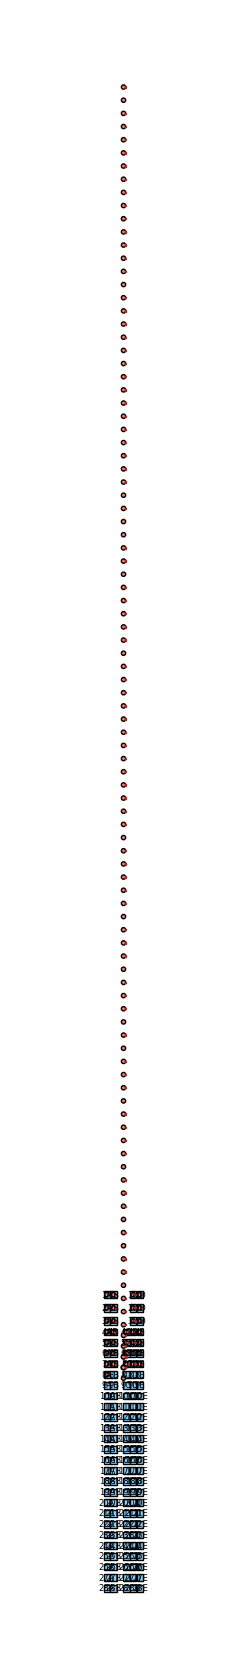

In [ ]:
plane_boarding = PlaneBoarding(num_of_passengers, plane, boarding_choice, Passenger)
plane_boarding.animate(frames = 100, interval = 1)